In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [9]:
# Task 1: Data acquisition & inspection
columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome'
]

file_path = '/home/fatih/Documents/Projects/penggalian-data/modul3/datasets/pima-indians-diabetes.data.csv'
df = pd.read_csv(file_path, header=None, names=columns)

print('First 10 rows:')
display(df.head(10))

First 10 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [10]:
# Task 2: Identifying hidden missing values (0 -> NaN for selected columns)
zero_as_missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_as_missing_cols] = df[zero_as_missing_cols].replace(0, np.nan)

print('\nMissing values per column after converting impossible 0 values to NaN:')
display(df.isna().sum())


Missing values per column after converting impossible 0 values to NaN:


Pregnancies           0
Glucose               5
BloodPressure        35
SkinThickness       227
Insulin             374
BMI                  11
DiabetesPedigree      0
Age                   0
Outcome               0
dtype: int64

In [11]:
# Task 3: Handling missing values with median imputation
for col in zero_as_missing_cols:
    df[col] = df[col].fillna(df[col].median())

print('\nMissing values per column after imputation:')
display(df.isna().sum())


Missing values per column after imputation:


Pregnancies         0
Glucose             0
BloodPressure       0
SkinThickness       0
Insulin             0
BMI                 0
DiabetesPedigree    0
Age                 0
Outcome             0
dtype: int64

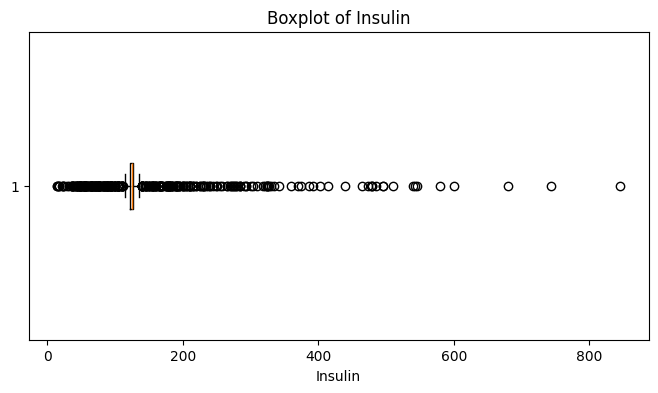

Number of data points beyond upper whisker in Insulin: 173
There are many/noticeable extreme values beyond the upper whisker.


In [12]:
 # Task 4: Outlier detection for Insulin using boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(df['Insulin'], vert=False)
plt.title('Boxplot of Insulin')
plt.xlabel('Insulin')
plt.show()

q1 = df['Insulin'].quantile(0.25)
q3 = df['Insulin'].quantile(0.75)
iqr = q3 - q1
upper_whisker = q3 + 1.5 * iqr
n_outliers_upper = (df['Insulin'] > upper_whisker).sum()

print(f'Number of data points beyond upper whisker in Insulin: {n_outliers_upper}')
if n_outliers_upper > 0:
    print('There are many/noticeable extreme values beyond the upper whisker.')
else:
    print('There are no data points beyond the upper whisker.')

In [13]:
# Task 5: Feature scaling (Min-Max normalization) for all columns
scaler = MinMaxScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print('\nMin value per column after normalization:')
display(df.min())
print('Max value per column after normalization:')
display(df.max())


Min value per column after normalization:


Pregnancies         0.0
Glucose             0.0
BloodPressure       0.0
SkinThickness       0.0
Insulin             0.0
BMI                 0.0
DiabetesPedigree    0.0
Age                 0.0
Outcome             0.0
dtype: float64

Max value per column after normalization:


Pregnancies         1.0
Glucose             1.0
BloodPressure       1.0
SkinThickness       1.0
Insulin             1.0
BMI                 1.0
DiabetesPedigree    1.0
Age                 1.0
Outcome             1.0
dtype: float64

In [14]:
# Final submission check
print('--- Data Info ---')
print(df.info())

print('\n--- Missing Values ---')
print(df.isna().sum())

print('\n--- Min/Max per Column ---')
display(df.describe().loc[['min', 'max']])

all_numeric = all(pd.api.types.is_numeric_dtype(dtype) for dtype in df.dtypes)
in_range_01 = ((df >= 0) & (df <= 1)).all().all()

print('\n--- Validation ---')
print(f'All columns numeric: {all_numeric}')
print(f'All values in [0, 1]: {in_range_01}')

print('\n--- Final Data Preview ---')
display(df.head())

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pregnancies       768 non-null    float64
 1   Glucose           768 non-null    float64
 2   BloodPressure     768 non-null    float64
 3   SkinThickness     768 non-null    float64
 4   Insulin           768 non-null    float64
 5   BMI               768 non-null    float64
 6   DiabetesPedigree  768 non-null    float64
 7   Age               768 non-null    float64
 8   Outcome           768 non-null    float64
dtypes: float64(9)
memory usage: 54.1 KB
None

--- Missing Values ---
Pregnancies         0
Glucose             0
BloodPressure       0
SkinThickness       0
Insulin             0
BMI                 0
DiabetesPedigree    0
Age                 0
Outcome             0
dtype: int64

--- Min/Max per Column ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



--- Validation ---
All columns numeric: True
All values in [0, 1]: False

--- Final Data Preview ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,0.352941,0.670968,0.489796,0.304348,0.133413,0.314928,0.234415,0.483333,1.0
1,0.058824,0.264516,0.428571,0.239130,0.133413,0.171779,0.116567,0.166667,0.0
2,0.470588,0.896774,0.408163,0.239130,0.133413,0.104294,0.253629,0.183333,1.0
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000,0.0
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000,1.0
